# Clase 7 -- Sistema Multiagente para Oncologia

## Parte 3: Supervisor + Agentes Especializados

---

### El proyecto completo

| Parte | Agente | Datos | Patron |
|---|---|---|---|
| **Parte 1** | Agente Clinico | Mind map XML de ACME (ensayo clinico CRISPR-Cas9) | Function calling manual |
| **Parte 2** | Agente Farmacologico | Base de datos de medicamentos NSCLC | MCP (Model Context Protocol) |
| **Parte 3** | **Supervisor + ambos agentes** | **Ambas fuentes combinadas** | **LangGraph (create_agent)** |

### De loops manuales a LangGraph

En las Partes 1 y 2, implementamos el agentic loop manualmente:

```
while True:
    response = llm.generate(messages, tools=tools)
    if response tiene function_calls:
        for cada function_call:
            resultado = ejecutar_tool(function_call)
            agregar resultado a messages
    else:
        return response.text  # respuesta final
```

En esta Parte 3 usamos **LangGraph** con `create_agent`, que implementa este loop internamente.
Nosotros solo necesitamos **conectar** las tools con los agentes y los agentes entre si.

```
Usuario -> Supervisor -> Sobre el ensayo clinico? -> Agente Clinico (XML)
                      -> Sobre medicamentos?      -> Agente Farmacologico (DB)
                      -> Cruza ambos dominios?     -> Ambos agentes -> Sintesis
```

## Setup

In [14]:
%pip install -q langchain langchain-google-genai langchain-core langgraph requests

Note: you may need to restart the kernel to use updated packages.


In [15]:
import requests
import xml.etree.ElementTree as ET
import json
import re
import unicodedata
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool

import warnings
warnings.filterwarnings('ignore')

print("Setup completo!")

Setup completo!


In [ ]:
GEMINI_API_KEY = ""
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=GEMINI_API_KEY)
print(f"Modelo configurado: gemini-2.5-flash")

Modelo configurado: gemini-2.5-flash


---

## Paso 1: Tools y datos del dominio clinico (Parte 1)

Las funciones que acceden al mind map XML de ACME Precision Oncology.

**No modifiques estas celdas.**

In [19]:
# ============================================================
# NO MODIFICAR - Agente Clinico (dado)
# ============================================================

# -- Datos del dominio clinico ----------------------------------------

XML_URL = "https://api.wisemapping.com/api/restful/maps/2030512/document/xml-pub"

def _parse_mindmap(xml_text: str) -> dict:
    root = ET.fromstring(xml_text)
    central = root.find('.//topic[@central="true"]')
    if central is None:
        central = root.find('.//topic')
    def get_text(node):
        t = node.get('text', '')
        if not t:
            te = node.find('text')
            if te is not None and te.text:
                t = te.text.strip()
        return t
    def get_note(node):
        ne = node.find('note')
        return ne.text.strip() if ne is not None and ne.text else ''
    def collect(node, depth=0):
        lines = []
        text = get_text(node)
        note = get_note(node)
        if text:
            indent = "  " * depth
            lines.append(f"{indent}- {text}")
            if note:
                lines.append(f"{indent}  (Nota: {note})")
        for child in node.findall('topic'):
            lines.extend(collect(child, depth + 1))
        return lines
    sections = {}
    central_text = get_text(central)
    for branch in central.findall('topic'):
        name = get_text(branch)
        if name:
            sections[name] = collect(branch)
    return central_text, sections


@tool
def fetch_full_xml() -> str:
    """Descarga y retorna TODOS los datos del mind map de ACME Precision Oncology como texto legible. Usar cuando se necesita una vision completa de la empresa o cuando la pregunta puede involucrar multiples secciones."""
    resp = requests.get(XML_URL)
    resp.raise_for_status()
    title, sections = _parse_mindmap(resp.text)
    output = f"=== {title} ===\n\n"
    for section_name, lines in sections.items():
        output += "\n".join(lines) + "\n\n"
    return output


@tool
def get_section(section_name: str) -> str:
    """Retorna los datos de UNA seccion especifica del mind map de ACME. Mas eficiente que fetch_full_xml cuando se sabe que seccion buscar. Secciones disponibles: Research Especifico, Datos Biomedicos Clave, Modelos Predictivos, Costos del Proyecto, Ensayos Clinicos, Impacto y Mercado, Riesgos, Futuro."""
    resp = requests.get(XML_URL)
    resp.raise_for_status()
    _, sections = _parse_mindmap(resp.text)
    for name, lines in sections.items():
        if section_name.lower() in name.lower():
            return f"Seccion: {name}\n" + "\n".join(lines)
    return f"Seccion '{section_name}' no encontrada. Disponibles: {', '.join(sections.keys())}"


@tool
def list_sections() -> str:
    """Lista todas las secciones principales disponibles en el mind map de ACME. Usar cuando no se sabe que secciones existen."""
    resp = requests.get(XML_URL)
    resp.raise_for_status()
    title, sections = _parse_mindmap(resp.text)
    result = f"Mind map: {title}\n\nSecciones disponibles:\n"
    for i, name in enumerate(sections.keys(), 1):
        result += f"  {i}. {name}\n"
    return result


@tool
def calculate(expression: str) -> str:
    """Evalua una expresion matematica. Usar para calculos como porcentajes, sumas, divisiones. Ejemplo: '420000000 * 0.68' o '85000 * 1200'."""
    cleaned = re.sub(r'[^0-9+\-*/().,%\s]', '', expression)
    cleaned = cleaned.replace('%', '/100').replace(',', '')
    try:
        result = eval(cleaned)
        return f"{expression} = {result}"
    except Exception as e:
        return f"Error: {e}"


# -- Agente Clinico --------------------------------------------------

clinical_tools = [fetch_full_xml, get_section, list_sections, calculate]

clinical_agent = create_agent(
    model,
    tools=clinical_tools,
    system_prompt=(
        "Eres un asistente experto en datos de ACME Precision Oncology. "
        "SIEMPRE usa las tools disponibles para obtener datos antes de responder. "
        "NUNCA inventes datos. Usa datos exactos tal como aparecen en la fuente. "
        "Responde de forma concisa y precisa."
    ),
)

print(f"Agente Clinico creado con {len(clinical_tools)} tools:")
for t in clinical_tools:
    print(f"  - {t.name}")

# Test rapido
result = clinical_agent.invoke({"messages": [("user", "Cuantos pacientes tiene la cohorte?")]})
print(f"\nTest: {result['messages'][-1].content[:200]}")

Agente Clinico creado con 4 tools:
  - fetch_full_xml
  - get_section
  - list_sections
  - calculate

Test: [{'type': 'text', 'text': 'La cohorte tiene 1,200 pacientes.', 'extras': {'signature': 'CoYCAb4+9vs/mdvT7onlMQC1VYVid9TUpUxkhAPL7+YZ2pQ5dN41C16fAyEFvfTv7JEgaJYVeixB6DdNWr6IWnpzOzS4zZAlP5xsbuNtYe0q/JU66FK18BqzUas9e/5dGMLN0x2GOXT1edx7qCil61QaPMYev5B/aGwerG57YCiPzCfAiNz70d65abCAgXtM0lRB0rYKfJBgbdqRHgr8OWPBNmW5JuEEbOT7qjZIGix1vE0CgWwLX31BZVU8IaBTSKvMlVPf3UoendzwtzYT6sj4r23qVR63u+KyBpT45gnjoPweubX7BfEJE1MH3q7s+A6/zSd9uo07zg2LvyRounxpBF0nsj0ptg=='}}]


---

## Paso 2: Datos del dominio farmacologico (Parte 2)

La base de datos de medicamentos para NSCLC.

**No modifiques estas celdas.**

In [20]:
# ============================================================
# NO MODIFICAR - Base de datos farmacologica (dada)
# ============================================================

PHARMA_DB = [
    {
        "name": "Osimertinib",
        "brand": "Tagrisso",
        "drug_class": "EGFR-TKI (3ra generacion)",
        "mechanism": "Inhibidor irreversible de EGFR mutado (L858R, del19, T790M). Se une covalentemente al residuo C797 del dominio kinasa.",
        "targets": ["EGFR-L858R", "EGFR-del19", "EGFR-T790M"],
        "indications": "NSCLC metastasico EGFR+ (1ra linea); NSCLC con T790M post-progresion a TKI previo (2da linea); adyuvante post-cirugia en NSCLC EGFR+ estadios IB-IIIA.",
        "dosage": "80 mg oral/dia (reducir a 40 mg si toxicidad grado 3+)",
        "contraindications": ["Hipersensibilidad al osimertinib", "Embarazo/lactancia", "Enfermedad pulmonar intersticial activa"],
        "side_effects": ["Diarrea (42%)", "Rash (34%)", "Piel seca (23%)", "Paroniquia (22%)", "Estomatitis (15%)", "Prolongacion QTc (3-5%)"],
        "cost_monthly_usd": 14000,
        "evidence": "Nivel 1A — estudios FLAURA (1ra linea), ADAURA (adyuvante), AURA3 (T790M)",
        "approval_year": 2017
    },
    {
        "name": "Erlotinib",
        "brand": "Tarceva",
        "drug_class": "EGFR-TKI (1ra generacion)",
        "mechanism": "Inhibidor reversible competitivo del dominio tirosina-kinasa de EGFR. Bloquea la señalizacion de proliferacion celular.",
        "targets": ["EGFR-L858R", "EGFR-del19"],
        "indications": "NSCLC metastasico EGFR+ (ya no es 1ra linea preferida). Combinacion con ramucirumab o bevacizumab.",
        "dosage": "150 mg oral/dia en ayunas (1h antes o 2h despues de comida)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Insuficiencia hepatica severa"],
        "side_effects": ["Rash acneiforme (75%)", "Diarrea (54%)", "Anorexia (30%)", "Fatiga (25%)", "Nauseas (20%)", "Hepatotoxicidad (2-5%)"],
        "cost_monthly_usd": 7500,
        "evidence": "Nivel 1A — estudio EURTAC, ENSURE",
        "approval_year": 2004
    },
    {
        "name": "Gefitinib",
        "brand": "Iressa",
        "drug_class": "EGFR-TKI (1ra generacion)",
        "mechanism": "Inhibidor reversible selectivo del dominio tirosina-kinasa de EGFR. Similar a erlotinib pero con perfil de selectividad ligeramente diferente.",
        "targets": ["EGFR-L858R", "EGFR-del19"],
        "indications": "NSCLC metastasico EGFR+ (alternativa a erlotinib en 1ra generacion).",
        "dosage": "250 mg oral/dia (con o sin alimentos)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Enfermedad pulmonar intersticial"],
        "side_effects": ["Diarrea (47%)", "Rash (44%)", "Piel seca (28%)", "Nauseas (18%)", "Elevacion transaminasas (10%)", "Enfermedad pulmonar intersticial (1-2%)"],
        "cost_monthly_usd": 6800,
        "evidence": "Nivel 1A — estudio IPASS, NEJ002",
        "approval_year": 2003
    },
    {
        "name": "Afatinib",
        "brand": "Gilotrif",
        "drug_class": "EGFR-TKI (2da generacion)",
        "mechanism": "Inhibidor irreversible pan-HER (EGFR/HER1, HER2, HER4). Bloquea toda la familia ErbB, no solo EGFR.",
        "targets": ["EGFR-L858R", "EGFR-del19", "HER2"],
        "indications": "NSCLC metastasico EGFR+ (alternativa, especialmente en del19). Tambien aprobado para carcinoma escamoso de pulmon post-platino.",
        "dosage": "40 mg oral/dia en ayunas (reducir a 30 mg o 20 mg si toxicidad)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Deterioro renal severo (ClCr <15 ml/min)"],
        "side_effects": ["Diarrea (96%)", "Rash (89%)", "Estomatitis (72%)", "Paroniquia (58%)", "Piel seca (31%)", "Disminucion del apetito (29%)"],
        "cost_monthly_usd": 8200,
        "evidence": "Nivel 1A — estudios LUX-Lung 3, LUX-Lung 6, LUX-Lung 7",
        "approval_year": 2013
    },
    {
        "name": "Pembrolizumab",
        "brand": "Keytruda",
        "drug_class": "Inmunoterapia anti-PD-1",
        "mechanism": "Anticuerpo monoclonal humanizado anti-PD-1. Bloquea el receptor PD-1 en linfocitos T, restaurando la respuesta inmune antitumoral.",
        "targets": ["PD-1"],
        "indications": "NSCLC metastasico PD-L1+ (>=1%) sin mutaciones driver (EGFR/ALK). Monoterapia si PD-L1>=50%; combinacion con quimio si PD-L1 1-49%.",
        "dosage": "200 mg IV cada 3 semanas (o 400 mg IV cada 6 semanas)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Enfermedad autoinmune activa severa", "Uso de inmunosupresores cronicos"],
        "side_effects": ["Fatiga (25%)", "Prurito (18%)", "Rash (15%)", "Diarrea (12%)", "Neumonitis inmunomediada (3-5%)", "Hepatitis inmunomediada (1-3%)", "Tiroiditis (8%)"],
        "cost_monthly_usd": 18000,
        "evidence": "Nivel 1A — estudios KEYNOTE-024 (monoterapia), KEYNOTE-189 (combo con quimio)",
        "approval_year": 2016
    },
    {
        "name": "Docetaxel",
        "brand": "Taxotere",
        "drug_class": "Quimioterapia (taxano)",
        "mechanism": "Estabiliza microtubulos impidiendo su despolimerizacion. Bloquea la mitosis celular en fase M del ciclo celular.",
        "targets": ["Microtubulos"],
        "indications": "NSCLC metastasico como 2da linea post-platino. Tambien en combinacion con cisplatino como 1ra linea.",
        "dosage": "75 mg/m2 IV cada 3 semanas (premedicacion con dexametasona obligatoria)",
        "contraindications": ["Neutrofilos <1500/mm3", "Hipersensibilidad a polisorbato 80", "Embarazo/lactancia", "Insuficiencia hepatica severa"],
        "side_effects": ["Neutropenia (75%)", "Alopecia (65%)", "Fatiga (53%)", "Nauseas (34%)", "Diarrea (25%)", "Neuropatia periferica (20%)", "Retencion de liquidos (15%)"],
        "cost_monthly_usd": 3500,
        "evidence": "Nivel 1A — estudio TAX 317, TAX 320",
        "approval_year": 1999
    },
    {
        "name": "Carboplatin",
        "brand": "Paraplatin",
        "drug_class": "Quimioterapia (platino)",
        "mechanism": "Forma aductos con el ADN generando enlaces cruzados inter e intracatenarios. Inhibe replicacion y transcripcion del ADN tumoral.",
        "targets": ["ADN"],
        "indications": "NSCLC metastasico en combinacion (carbo + pemetrexed, carbo + paclitaxel). Base de muchos esquemas de 1ra linea sin mutacion driver.",
        "dosage": "AUC 5-6 IV cada 3 semanas (calcular dosis por formula de Calvert)",
        "contraindications": ["Hipersensibilidad a compuestos de platino", "Mielosupresion severa", "Embarazo/lactancia", "Insuficiencia renal severa (ClCr <15 ml/min)"],
        "side_effects": ["Trombocitopenia (62%)", "Neutropenia (55%)", "Anemia (48%)", "Nauseas/vomitos (45%)", "Fatiga (35%)", "Nefrotoxicidad (10%)", "Ototoxicidad (5%)"],
        "cost_monthly_usd": 800,
        "evidence": "Nivel 1A — multiples estudios fase III como base de combinaciones",
        "approval_year": 1989
    },
    {
        "name": "Pemetrexed",
        "brand": "Alimta",
        "drug_class": "Quimioterapia (antifolato)",
        "mechanism": "Antifolato multitarget que inhibe timidilato sintasa (TS), dihidrofolato reductasa (DHFR) y glicinamida ribonucleotido formiltransferasa (GARFT).",
        "targets": ["TS", "DHFR", "GARFT"],
        "indications": "NSCLC no escamoso metastasico en combinacion con platino (1ra linea) y como mantenimiento. NO indicado en histologia escamosa.",
        "dosage": "500 mg/m2 IV cada 3 semanas (suplementar con acido folico y vitamina B12 obligatorio)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "ClCr <45 ml/min", "Histologia escamosa de NSCLC"],
        "side_effects": ["Neutropenia (40%)", "Fatiga (35%)", "Nauseas (30%)", "Anemia (20%)", "Estomatitis (15%)", "Rash (10%)", "Elevacion de creatinina (8%)"],
        "cost_monthly_usd": 6000,
        "evidence": "Nivel 1A — estudio PARAMOUNT (mantenimiento), JMDB (1ra linea con cisplatino)",
        "approval_year": 2004
    },
    {
        "name": "Bevacizumab",
        "brand": "Avastin",
        "drug_class": "Antiangiogenico (anti-VEGF)",
        "mechanism": "Anticuerpo monoclonal anti-VEGF-A. Inhibe la angiogenesis tumoral impidiendo la union de VEGF a sus receptores.",
        "targets": ["VEGF-A"],
        "indications": "NSCLC no escamoso metastasico en combinacion con quimioterapia (carbo + paclitaxel + bev). NO usar en histologia escamosa (riesgo hemoptisis).",
        "dosage": "15 mg/kg IV cada 3 semanas (o 7.5 mg/kg cada 3 semanas en algunos esquemas)",
        "contraindications": ["Histologia escamosa", "Hemoptisis reciente", "Cirugia mayor reciente (<28 dias)", "Hipertension no controlada", "Embarazo/lactancia"],
        "side_effects": ["Hipertension (25%)", "Proteinuria (20%)", "Epistaxis (15%)", "Fatiga (12%)", "Hemorragia (8%)", "Perforacion GI (1-2%)", "Tromboembolismo arterial (3%)"],
        "cost_monthly_usd": 9500,
        "evidence": "Nivel 1A — estudio ECOG 4599, AVAiL",
        "approval_year": 2006
    },
    {
        "name": "Crizotinib",
        "brand": "Xalkori",
        "drug_class": "Inhibidor ALK/ROS1",
        "mechanism": "Inhibidor de tirosina kinasa de ALK, ROS1 y MET. Bloquea la señalizacion oncogenica en tumores con reordenamientos ALK o ROS1.",
        "targets": ["ALK", "ROS1", "MET"],
        "indications": "NSCLC metastasico ALK+ (ya no es 1ra linea preferida, reemplazado por alectinib). NSCLC ROS1+.",
        "dosage": "250 mg oral cada 12 horas (con o sin alimentos)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Prolongacion QTc congenita", "Insuficiencia hepatica severa"],
        "side_effects": ["Trastornos visuales (62%)", "Nauseas (55%)", "Diarrea (43%)", "Vomitos (40%)", "Edema (30%)", "Elevacion transaminasas (15%)", "Bradicardia (5%)"],
        "cost_monthly_usd": 16000,
        "evidence": "Nivel 1A — estudio PROFILE 1014 (ALK), PROFILE 1001 (ROS1)",
        "approval_year": 2011
    }
]

INTERACTIONS_DB = [
    {"drug_a": "Osimertinib", "drug_b": "Erlotinib", "severity": "CONTRAINDICADO", "detail": "Mismo target EGFR — toxicidad aditiva sin beneficio clinico. No combinar TKIs del mismo target."},
    {"drug_a": "Osimertinib", "drug_b": "Gefitinib", "severity": "CONTRAINDICADO", "detail": "Mismo target EGFR — toxicidad aditiva sin beneficio clinico."},
    {"drug_a": "Osimertinib", "drug_b": "Afatinib", "severity": "CONTRAINDICADO", "detail": "Ambos inhiben EGFR — riesgo de toxicidad severa (rash, diarrea, prolongacion QTc)."},
    {"drug_a": "Erlotinib", "drug_b": "Gefitinib", "severity": "CONTRAINDICADO", "detail": "Ambos son EGFR-TKI 1ra generacion — mecanismo identico, sin beneficio en combinacion."},
    {"drug_a": "Osimertinib", "drug_b": "Warfarina", "severity": "PRECAUCION", "detail": "Osimertinib es sustrato e inhibidor de CYP3A4. Monitorear INR frecuentemente — riesgo de sangrado aumentado."},
    {"drug_a": "Erlotinib", "drug_b": "Warfarina", "severity": "PRECAUCION", "detail": "Erlotinib inhibe CYP1A2 y CYP3A4. Monitorear INR — reportes de sangrado con uso concomitante."},
    {"drug_a": "Pembrolizumab", "drug_b": "Corticoides", "severity": "PRECAUCION", "detail": "Dosis altas de corticoides (>10 mg prednisona/dia) pueden reducir eficacia de inmunoterapia al suprimir linfocitos T."},
    {"drug_a": "Pembrolizumab", "drug_b": "Osimertinib", "severity": "PRECAUCION", "detail": "Combinacion asociada a mayor incidencia de neumonitis inmunomediada. No recomendada de rutina."},
    {"drug_a": "Carboplatin", "drug_b": "Pemetrexed", "severity": "COMPATIBLE", "detail": "Combinacion estandar de 1ra linea para NSCLC no escamoso. Esquema validado en multiples estudios fase III."},
    {"drug_a": "Carboplatin", "drug_b": "Docetaxel", "severity": "COMPATIBLE", "detail": "Combinacion usada en 1ra linea. Monitorear mielosupresion aditiva (neutropenia)."},
    {"drug_a": "Carboplatin", "drug_b": "Bevacizumab", "severity": "COMPATIBLE", "detail": "Combinacion estandar (carbo + paclitaxel + bev). Solo en histologia no escamosa."},
    {"drug_a": "Carboplatin", "drug_b": "Pembrolizumab", "severity": "COMPATIBLE", "detail": "Combinacion aprobada: carbo + pemetrexed + pembrolizumab (KEYNOTE-189). Esquema estandar para NSCLC no escamoso sin driver."},
    {"drug_a": "Docetaxel", "drug_b": "Bevacizumab", "severity": "PRECAUCION", "detail": "Combinacion posible pero monitorear neutropenia severa y riesgo de sangrado."},
    {"drug_a": "Pemetrexed", "drug_b": "AINEs", "severity": "PRECAUCION", "detail": "AINEs reducen eliminacion renal de pemetrexed. Suspender AINEs 2-5 dias antes de cada ciclo."},
    {"drug_a": "Bevacizumab", "drug_b": "Anticoagulantes", "severity": "PRECAUCION", "detail": "Riesgo aumentado de hemorragia. Monitorear signos de sangrado y ajustar dosis de anticoagulante."},
    {"drug_a": "Crizotinib", "drug_b": "Osimertinib", "severity": "PRECAUCION", "detail": "Ambos prolongan QTc. Si se combinan, monitorear ECG. Targets diferentes (ALK vs EGFR) pero toxicidad cardiaca aditiva."},
    {"drug_a": "Gefitinib", "drug_b": "Omeprazol", "severity": "PRECAUCION", "detail": "IBP reducen absorcion de gefitinib (requiere pH acido). Evitar IBP o usar anti-H2 con separacion de 12h."},
    {"drug_a": "Afatinib", "drug_b": "P-gp inductores", "severity": "PRECAUCION", "detail": "Rifampicina y otros inductores de P-gp reducen niveles de afatinib. Ajustar dosis si uso concomitante necesario."}
]

print(f"Base de datos cargada: {len(PHARMA_DB)} medicamentos, {len(INTERACTIONS_DB)} interacciones")

Base de datos cargada: 10 medicamentos, 18 interacciones


---

## Ejercicio 1: Conectar las tools farmacologicas con LangGraph

Las funciones que acceden a la base de datos ya estan implementadas arriba.
Ahora necesitas **conectarlas como tools de LangGraph** usando el decorador `@tool`.

El decorador `@tool` convierte una funcion Python en una tool que el agente puede usar.
El LLM lee el **docstring** de la funcion para decidir cuando usarla -- funciona como
la "descripcion" que escribiste en las Partes 1 y 2.

```python
@tool
def mi_tool(parametro: str) -> str:
    """Esta descripcion es lo que lee el LLM para decidir cuando usar esta tool."""
    return resultado
```

**Tu tarea:**
1. Decorar las 4 funciones con `@tool`
2. Escribir un **docstring** descriptivo para cada una (que hace, cuando usarla, que retorna)
3. Las funciones internamente ya tienen la logica implementada

In [21]:
# -- TODO: Conectar las tools farmacologicas con @tool ----------

@tool
def search_drug(drug_name: str) -> str:
    "Busca un medicamento en la base de datos a partir de su nombre generico o comercial (marca). "
    "Usar esta herramienta cuando el usuario menciona un farmaco especifico y se necesita obtener informacion general sobre el mismo. "
    "No usar si se busca comparar multiples medicamentos, listar por clase o analizar interacciones. "
    "Devuelve un objeto indicando si el medicamento fue encontrado y, en caso afirmativo, un diccionario con toda su informacion (nombre, marca, clase, indicaciones, targets, evidencia, costo, etc.)."
    name_lower = drug_name.lower().strip()
    for drug in PHARMA_DB:
        if name_lower in drug["name"].lower() or name_lower in drug["brand"].lower():
            return json.dumps(drug, indent=2, ensure_ascii=False)
    return f"Medicamento '{drug_name}' no encontrado."


@tool
def check_interaction(drug_a: str, drug_b: str) -> str:
    "Verifica si existe una interaccion conocida entre dos medicamentos en la base de datos. "
    "Usar esta herramienta cuando el usuario pregunta por combinaciones de farmacos o posibles riesgos al administrarlos juntos. "
    "No usar para buscar informacion individual de un farmaco o listar tratamientos. "
    "Devuelve un objeto indicando si se encontro una interaccion y, en caso positivo, detalles de la misma (descripcion, severidad, recomendaciones). "
    "Si no se encuentra, devuelve un mensaje indicando que no hay interaccion registrada."
    a_lower = drug_a.lower().strip()
    b_lower = drug_b.lower().strip()
    for ix in INTERACTIONS_DB:
        ia, ib = ix["drug_a"].lower(), ix["drug_b"].lower()
        if (a_lower in ia or a_lower in ib) and (b_lower in ia or b_lower in ib):
            return json.dumps(ix, indent=2, ensure_ascii=False)
    return f"No se encontro interaccion entre '{drug_a}' y '{drug_b}'."


@tool
def list_drugs_by_class(drug_class: str) -> str:
    "Lista todos los medicamentos pertenecientes a una clase terapeutica especifica "
    "(por ejemplo: EGFR, inmunoterapia, platino, etc.). "
    "Usar esta tool cuando el usuario quiera explorar opciones dentro de una misma clase "
    "o comparar farmacos similares. "
    "IMPORTANTE: el parametro 'drug_class' debe ser un termino clave presente en la base de datos "
    "(por ejemplo: 'EGFR', no 'inhibidores de EGFR'). "
    "No usar para buscar informacion de un farmaco puntual ni para targets moleculares especificos. "
    "Devuelve un objeto con la cantidad de medicamentos encontrados y una lista con informacion resumida de cada uno (nombre, marca, clase y costo mensual)."
    class_lower = drug_class.lower().strip()
    matches = [
        {"name": d["name"], "brand": d["brand"], "drug_class": d["drug_class"], "cost_monthly_usd": d["cost_monthly_usd"]}
        for d in PHARMA_DB if class_lower in d["drug_class"].lower()
    ]
    if matches:
        return json.dumps(matches, indent=2, ensure_ascii=False)
    classes = sorted(set(d["drug_class"] for d in PHARMA_DB))
    return f"Clase '{drug_class}' no encontrada. Disponibles: {', '.join(classes)}"


@tool
def get_treatment_options(target: str) -> str:
    "Obtiene medicamentos que actuan sobre un target molecular especifico (por ejemplo EGFR, ALK o PD-1). "
    "Usar esta herramienta cuando el usuario pregunta por tratamientos dirigidos segun biomarcadores o mutaciones. "
    "No usar para busquedas por nombre de farmaco ni para clases generales. "
    "Devuelve un objeto con la cantidad de opciones encontradas y una lista de medicamentos con informacion relevante (nombre, marca, clase, indicaciones clinicas y nivel de evidencia)."
    target_upper = target.upper().strip()
    matches = [
        {"name": d["name"], "brand": d["brand"], "drug_class": d["drug_class"], "indications": d["indications"], "evidence": d["evidence"]}
        for d in PHARMA_DB if any(target_upper in t.upper() for t in d["targets"])
    ]
    if matches:
        return json.dumps(matches, indent=2, ensure_ascii=False)
    all_targets = sorted(set(t for d in PHARMA_DB for t in d["targets"]))
    return f"Target '{target}' no encontrado. Disponibles: {', '.join(all_targets)}"


pharma_tools = [search_drug, check_interaction, list_drugs_by_class, get_treatment_options]

# Verificar
for t in pharma_tools:
    desc = t.description or "(SIN DESCRIPCION)"
    print(f"  {'OK' if t.description else 'FALTA'}: {t.name} -- {desc[:60]}")

  OK: search_drug -- Busca un medicamento en la base de datos a partir de su nomb
  OK: check_interaction -- Verifica si existe una interaccion conocida entre dos medica
  OK: list_drugs_by_class -- Lista todos los medicamentos pertenecientes a una clase tera
  OK: get_treatment_options -- Obtiene medicamentos que actuan sobre un target molecular es


---

## Ejercicio 2: Crear el agente farmacologico con LangGraph

Usa `create_agent` para crear el agente farmacologico.
Necesitas pasarle:
- El **modelo** (ya creado como `model`)
- Las **tools** (la lista `pharma_tools` del ejercicio anterior)
- Un **system_prompt** que le diga al agente que es, que debe hacer y que NO debe hacer

In [29]:
# -- TODO: Crear el agente farmacologico --------------------------

pharma_agent = create_agent(
    model,
    tools=pharma_tools,
    system_prompt=""""
Eres un asistente farmacologico especializado en oncologia (NSCLC) que trabaja con una base de datos estructurada de medicamentos.

ROL:
Tu funcion es ayudar a responder consultas sobre farmacos, interacciones, clases terapeuticas y tratamientos dirigidos a targets moleculares, utilizando exclusivamente las herramientas disponibles.

REGLA DE ORO:
- SIEMPRE debes usar las tools para obtener informacion.
- NUNCA inventes datos, medicamentos, interacciones o evidencia.
- Si la tool no devuelve resultados, debes informarlo claramente.

IDENTIFICACION DE INTENCION:

- Si la consulta menciona un medicamento especifico (ej: osimertinib):
  → SIEMPRE usa 'search_drug', independientemente del tipo de pregunta.

  Esto incluye preguntas sobre:
  - indicaciones
  - efectos secundarios
  - mecanismo de accion
  - targets moleculares
  - dosis
  - evidencia clinica
  - costo
  - cualquier otra informacion del farmaco

- Si menciona combinaciones o interacciones → usa 'check_interaction'

- Si menciona clases (ej: "EGFR", "inhibidores") → usa 'list_drugs_by_class'

- Si menciona targets moleculares → usa 'get_treatment_options'

USO DE TOOLS:
- Antes de responder, analiza si la consulta puede resolverse con una tool.
- Si existe una tool aplicable, debes usarla obligatoriamente.
- No respondas sin usar tools si la informacion esta disponible en ellas.
- Para preguntas sobre un medicamento especifico, SIEMPRE debes usar 'search_drug',
  aunque la pregunta sea sobre un atributo particular (ej: efectos secundarios).

FORMATO DE RESPUESTA:
- Responde de forma clara, concisa y estructurada.
- Usa bullet points cuando haya multiples resultados.
- No omitas informacion relevante.

REGLAS DE CONTENIDO:
- Si la tool devuelve multiples resultados, debes listarlos todos.
- Si devuelve un unico medicamento, debes responder especificamente la pregunta del usuario usando sus datos.
- No te limites a describir el farmaco: enfocate en la consulta (ej: efectos secundarios, dosis, etc.).

- Para cada medicamento incluye:
  - Nombre generico
  - Nombre comercial (brand)
  - Clase terapeutica

- Incluye contexto clinico clave (ej: 1ra linea, 2da linea, no escamoso).
- No resumas informacion critica.

- Cuando una combinacion de farmacos sea valida, debes indicar explicitamente:
  - "COMPATIBLE"
  - "1ra linea" si corresponde
  - tipo de paciente (ej: "no escamoso")

- Cuando un farmaco no deba usarse en un contexto, debes usar explicitamente la palabra "CONTRAINDICADO".

- Cuando describas indicaciones de un farmaco, incluye:
  - tipo de cancer (ej: NSCLC)
  - tipo de alteracion molecular (ej: "reordenamientos ALK", "mutacion EGFR")

ACLARACION IMPORTANTE SOBRE DOSIS:
- SI debes proporcionar dosis cuando esten disponibles en la base de datos.
- La dosis es informacion objetiva del farmaco.
- NO debes ajustar, interpretar ni personalizar la dosis.
- Solo debes reportar la dosis exactamente como aparece en la tool.

FORMATO DE NUMEROS:
- Escribe numeros sin separadores de miles (ej: 18000, no 18,000).

MANEJO DE ERRORES:
- Si no se encuentra informacion, indicalo explicitamente.
- Si la informacion solicitada (ej: efectos secundarios) no esta presente en los datos del medicamento,
  debes indicarlo explicitamente y no inventar contenido.

SEGURIDAD:
- La informacion es de referencia y no reemplaza al medico.
- No des recomendaciones personalizadas.

OBJETIVO:
Brindar informacion precisa, completa y estructurada basada exclusivamente en datos de las tools.
""",
)

# Test
result = pharma_agent.invoke({"messages": [("user", "Cual es la dosis de osimertinib?")]})
print(f"Test: {result['messages'][-1].content[:200]}")

Test: [{'type': 'text', 'text': 'Aquí tienes la información sobre la dosis de osimertinib:\n\n*   **Nombre genérico:** Osimertinib\n*   **Nombre comercial (brand):** Tagrisso\n*   **Clase terapéutica:** EGFR-TKI (3ra generación)\n*   **Dosis:** 80 mg oral/día (reducir a 40 mg si toxicidad grado 3+)', 'extras': {'signature': 'CscDAb4+9vsee8F1hifj/rgehwYl/jO8mb/1c6hbLF0YXIn8XMX1GhnW99w7oaOVE7ZIYhMQJELABK+V4G8p/Nll187HGx8ioluUARKOZlVtdYTuji8OZYQgi0i2nwcbgRKdipLTo0ZLhoPrwePxqEv7yN008bWiR9A7CIWy7onOqef/iATpuBkZtEaXQBGQjL5gzH3QZOVxV8+X0VuWo+rjMKtNhasFmYkd0WeVuLLut5yXc2WwAtGfVPvyUdxs5zqb3pRo6qFBm309/nBghU8yrG0kGh2mrO4ePO8mz/7roMhysaUtEk4Ix4A0y26fPYxy0vABkHYE29XKwqihb88gzhBMtM1EDaD7uQVTzzV0T+qyfTxxJHYU9/+mspp6retoe0ItU0gRAQypBzxmUml3OYftoUVCt8brrzujwKyroWXEm9F7SXuV/o5CF8t3VeK02GBnpnCq/BRi4t8fdRlB22eP+/UfDAdKMkoPlxwz6eOls8VyfFZi9PN/vuxG0C8hG0TWk/VOgYp9UbbZC5QAnlvKvzbh2oyWsY9qWucmxYHonpUQPQnhmysRLPaHZeDGlHgupLbso8p3Z/P5HcgVnEi2Vwrpod0='}}]


---

## Ejercicio 3: Crear las tools de routing del supervisor

El supervisor necesita 3 tools que **derivan preguntas a los sub-agentes**.
Cada tool es una funcion Python decorada con `@tool` que internamente
llama a un sub-agente con `agent.invoke()`.

**Tu tarea:**
1. Implementar `ask_clinical_agent` -- llama a `clinical_agent.invoke()`
2. Implementar `ask_pharma_agent` -- llama a `pharma_agent.invoke()`
3. Implementar `ask_both_agents` -- llama a AMBOS y combina las respuestas
4. Escribir docstrings descriptivos para cada una

**Pista:** Para invocar un agente y obtener la respuesta:
```python
result = agent.invoke({"messages": [("user", question)]})
respuesta = result["messages"][-1].content
```

In [30]:
# -- TODO: Implementar las tools de routing -----------------------

routing_log = []  # registro de routing (no modificar)

@tool
def ask_clinical_agent(question: str) -> str:
    """Usar esta tool cuando la pregunta este relacionada con datos clinicos,
    ensayos, cohortes de pacientes, resultados del estudio ACME o informacion
    del mind map (impacto, costos, modelos, etc.)
    No usar para preguntas sobre medicamentos específicos, interacciones,
    clases terapéuticas o tratamientos farmacológicos.
    Retorna la respuesta generada por el agente clínico en lenguaje natural."""
    routing_log.append({"tool": "ask_clinical_agent", "question": question})
    result = clinical_agent.invoke({
        "messages": [("user", question)]
    })
    return result["messages"][-1].content


@tool
def ask_pharma_agent(question: str) -> str:
    """
    Usa esta herramienta cuando la pregunta esté relacionada con farmacología oncológica.
    Esto incluye:
    - Medicamentos específicos (ej: osimertinib, pembrolizumab)
    - Interacciones entre fármacos
    - Clases terapéuticas (ej: EGFR inhibitors)
    - Targets moleculares y tratamientos asociados
    - Dosis, mecanismos de accion, efectos adversos
    No usar para preguntas sobre estrategia empresarial, reportes o contenido del mind map.
    Retorna la respuesta generada por el agente farmacológico en formato claro y estructurado.
    """
    routing_log.append({"tool": "ask_pharma_agent", "question": question})
    result = pharma_agent.invoke({
        "messages": [("user", question)]
    })
    return result["messages"][-1].content


@tool
def ask_both_agents(question: str) -> str:
    """
    Usa esta herramienta cuando la pregunta combina aspectos clínicos/estratégicos
    y farmacológicos.

    Ejemplos:
    - Preguntas que requieren contexto del mind map + información de medicamentos
    - Análisis que involucra estrategia y tratamientos
    - Consultas ambiguas donde ambos agentes pueden aportar valor

    Esta tool consulta ambos agentes y combina sus respuestas.

    Retorna:
    - Primero la respuesta del agente clínico
    - Luego la del agente farmacológico
    """
    routing_log.append({"tool": "ask_both_agents", "question": question})
    result_clinical = clinical_agent.invoke({"messages": [("user", question)]})
    resp_clinical = result_clinical["messages"][-1].content

    result_pharma = pharma_agent.invoke({"messages": [("user", question)]})
    resp_pharma = result_pharma["messages"][-1].content

    combined_response = (
        "=== Respuesta del Agente Clinico ===\n"
        f"{resp_clinical}\n\n"
        "=== Respuesta del Agente Farmacologico ===\n"
        f"{resp_pharma}"
    )
    return combined_response


supervisor_tools = [ask_clinical_agent, ask_pharma_agent, ask_both_agents]
print(f"Tools de routing: {[t.name for t in supervisor_tools]}")

Tools de routing: ['ask_clinical_agent', 'ask_pharma_agent', 'ask_both_agents']


---

## Ejercicio 4: Crear el supervisor con LangGraph

Usa `create_agent` para crear el supervisor.
El system prompt debe explicarle:
- Que agentes tiene disponibles y que sabe cada uno
- Cuando derivar a uno, al otro, o a ambos
- Que NUNCA debe inventar datos

In [48]:
# -- TODO: Crear el supervisor -------------------------------------

supervisor = create_agent(
    model,
    tools=supervisor_tools,
    system_prompt="""
Eres un supervisor inteligente que enruta preguntas a agentes especializados en oncologia (NSCLC).

DISPONES DE 2 AGENTES:

1) Agente Clinico:
- Especializado en datos del estudio ACME Precision Oncology
- Maneja: cohortes de pacientes, ensayos clinicos, resultados, modelos predictivos, costos, impacto y riesgos
- Fuente: mind map estructurado

2) Agente Farmacologico:
- Especializado en medicamentos oncologicos
- Maneja: dosis, mecanismos de accion, efectos adversos, interacciones, clases terapeuticas y targets moleculares (EGFR, ALK, PD-1, etc.)

TU TAREA:
- Analizar cada pregunta del usuario
- Decidir a que agente derivarla usando las tools disponibles

REGLAS DE ROUTING:

- Usa 'ask_clinical_agent' si la pregunta es sobre:
  - Ensayos clinicos
  - Datos de pacientes o cohortes
  - Resultados del estudio
  - Modelos predictivos
  - Costos, impacto o riesgos del proyecto ACME

- Usa 'ask_pharma_agent' si la pregunta es sobre:
  - Medicamentos especificos (ej: osimertinib, pembrolizumab)
  - Dosis
  - Mecanismos de accion
  - Efectos adversos
  - Interacciones
  - Clases terapeuticas
  - Targets moleculares

- Usa 'ask_both_agents' si la pregunta:
  - Combina contexto clinico + tratamiento farmacologico
  - Requiere decisiones terapeuticas basadas en datos clinicos
  - Es ambigua y ambos agentes pueden aportar valor

REGLA CRITICA:
- SIEMPRE debes usar una tool para responder
- NUNCA respondas directamente sin usar tools
- NUNCA inventes información
- NO combines respuestas por tu cuenta — usa la tool ask_both_agents

FORMATO:
- Devuelve exactamente la respuesta de la tool elegida
- No agregues informacion adicional
- Responde en español

OBJETIVO:
Seleccionar correctamente el agente adecuado para cada consulta y devolver respuestas precisas basadas en datos reales.

""",
)
print("Supervisor creado.")

Supervisor creado.


In [49]:
def ask_supervisor(question: str, verbose: bool = True) -> str:
    """Wrapper para llamar al supervisor y mostrar el flujo."""
    if verbose:
        print(f"\n{'='*60}")
        print(f"Usuario: {question}")
        print(f"{'='*60}")

    # Limpiar log para esta pregunta
    initial_log_len = len(routing_log)

    result = supervisor.invoke({"messages": [("user", question)]})
    answer = result["messages"][-1].content
    if isinstance(answer, list):
        answer = " ".join(str(x) for x in answer)

    if verbose:
        # Mostrar routing
        new_entries = routing_log[initial_log_len:]
        if new_entries:
            for entry in new_entries:
                print(f"\n  -> Routing: {entry['tool']}('{entry['question'][:60]}...')")
        print(f"\nSupervisor: {answer}")

    return answer

---

## Pruebas manuales

In [50]:
# Pregunta 1: Solo dominio clinico
ask_supervisor("Cual es la tasa de respuesta del tratamiento de ACME?")


Usuario: Cual es la tasa de respuesta del tratamiento de ACME?

  -> Routing: ask_clinical_agent('Cual es la tasa de respuesta del tratamiento de ACME?...')

Supervisor: La tasa de respuesta inicial del tratamiento de ACME es del 68%.


'La tasa de respuesta inicial del tratamiento de ACME es del 68%.'

In [51]:
# Pregunta 2: Solo dominio farmacologico
ask_supervisor("Cuales son los efectos secundarios de osimertinib?")


Usuario: Cuales son los efectos secundarios de osimertinib?

  -> Routing: ask_pharma_agent('Cuales son los efectos secundarios de osimertinib?...')

Supervisor: Aquí están los efectos secundarios de Osimertinib (nombre comercial: Tagrisso), un medicamento de la clase terapéutica EGFR-TKI (3ra generación):

*   Diarrea (42%)
*   Rash (34%)
*   Piel seca (23%)
*   Paroniquia (22%)
*   Estomatitis (15%)
*   Prolongación QTc (3-5%)


'Aquí están los efectos secundarios de Osimertinib (nombre comercial: Tagrisso), un medicamento de la clase terapéutica EGFR-TKI (3ra generación):\n\n*   Diarrea (42%)\n*   Rash (34%)\n*   Piel seca (23%)\n*   Paroniquia (22%)\n*   Estomatitis (15%)\n*   Prolongación QTc (3-5%)'

In [52]:
# Pregunta 3: Cruza ambos dominios
ask_supervisor("Como se compara la terapia de ACME con osimertinib para tratar NSCLC con mutacion EGFR-L858R?")


Usuario: Como se compara la terapia de ACME con osimertinib para tratar NSCLC con mutacion EGFR-L858R?

  -> Routing: ask_both_agents('Como se compara la terapia de ACME con osimertinib para trat...')

Supervisor: La terapia de ACME Precision Oncology está desarrollando una terapia génica basada en CRISPR-Cas9 dirigida específicamente a la mutación EGFR-L858R en NSCLC. Los datos clave de esta terapia, basados en ensayos preclínicos y modelos de IA (simulados), son:

*   **Tasa de respuesta inicial:** 68%
*   **Reducción tumoral promedio:** 45%
*   **Supervivencia a 12 meses:** 72%

La información disponible no incluye una comparación directa de la terapia de ACME con osimertinib.

=== Respuesta del Agente Farmacologico ===
No se encontró información sobre el medicamento 'ACME' en la base de datos, por lo que no es posible compararlo.

Sin embargo, aquí tienes la información sobre Osimertinib para el tratamiento de NSCLC con mutación EGFR-L858R:

*   **Nombre genérico:** Osimertinib
* 

"La terapia de ACME Precision Oncology está desarrollando una terapia génica basada en CRISPR-Cas9 dirigida específicamente a la mutación EGFR-L858R en NSCLC. Los datos clave de esta terapia, basados en ensayos preclínicos y modelos de IA (simulados), son:\n\n*   **Tasa de respuesta inicial:** 68%\n*   **Reducción tumoral promedio:** 45%\n*   **Supervivencia a 12 meses:** 72%\n\nLa información disponible no incluye una comparación directa de la terapia de ACME con osimertinib.\n\n=== Respuesta del Agente Farmacologico ===\nNo se encontró información sobre el medicamento 'ACME' en la base de datos, por lo que no es posible compararlo.\n\nSin embargo, aquí tienes la información sobre Osimertinib para el tratamiento de NSCLC con mutación EGFR-L858R:\n\n*   **Nombre genérico:** Osimertinib\n*   **Nombre comercial:** Tagrisso\n*   **Clase terapéutica:** EGFR-TKI (3ra generación)\n*   **Indicaciones:**\n    *   NSCLC metastásico EGFR+ (1ra línea), incluyendo mutaciones EGFR-L858R.\n    *   N

In [54]:
# Pregunta 4: Cruza ambos dominios
ask_supervisor("Si un paciente del ensayo de ACME necesita tratamiento complementario, que opciones farmacologicas existen para EGFR-L858R?")


Usuario: Si un paciente del ensayo de ACME necesita tratamiento complementario, que opciones farmacologicas existen para EGFR-L858R?

  -> Routing: ask_both_agents('Si un paciente del ensayo de ACME necesita tratamiento compl...')

Supervisor: El Agente Clínico indica que la información sobre opciones farmacológicas complementarias para EGFR-L858R no está disponible en los datos proporcionados, ya que se centran en la investigación específica de ACME en terapia génica y edición genética para esta mutación.

El Agente Farmacológico proporciona las siguientes opciones farmacológicas para el tratamiento de NSCLC con la mutación EGFR-L858R:

*   **Osimertinib** (nombre comercial: Tagrisso)
    *   **Clase terapéutica:** EGFR-TKI (3ra generación)
    *   **Indicaciones:**
        *   NSCLC metastásico EGFR+ (1ra línea)
        *   NSCLC con T790M post-progresión a TKI previo (2da línea)
        *   Adyuvante post-cirugía en NSCLC EGFR+ estadios IB-IIIA.

*   **Erlotinib** (nombre comercial

'El Agente Clínico indica que la información sobre opciones farmacológicas complementarias para EGFR-L858R no está disponible en los datos proporcionados, ya que se centran en la investigación específica de ACME en terapia génica y edición genética para esta mutación.\n\nEl Agente Farmacológico proporciona las siguientes opciones farmacológicas para el tratamiento de NSCLC con la mutación EGFR-L858R:\n\n*   **Osimertinib** (nombre comercial: Tagrisso)\n    *   **Clase terapéutica:** EGFR-TKI (3ra generación)\n    *   **Indicaciones:**\n        *   NSCLC metastásico EGFR+ (1ra línea)\n        *   NSCLC con T790M post-progresión a TKI previo (2da línea)\n        *   Adyuvante post-cirugía en NSCLC EGFR+ estadios IB-IIIA.\n\n*   **Erlotinib** (nombre comercial: Tarceva)\n    *   **Clase terapéutica:** EGFR-TKI (1ra generación)\n    *   **Indicaciones:** NSCLC metastásico EGFR+ (ya no es 1ra línea preferida). Puede usarse en combinación con ramucirumab o bevacizumab.\n\n*   **Gefitinib** (

---

## Benchmark

**No modifiques estas celdas.**

In [55]:
# ============================================================
# NO MODIFICAR - Benchmark y funciones de evaluacion
# ============================================================

BENCHMARK = [
    {
        "id": "B01",
        "question": "Cuantos pacientes tiene la cohorte del ensayo de ACME?",
        "expected_routing": "clinical",
        "expected_keywords": ["1200", "1,200"],
        "expected_info": "1,200 pacientes en la cohorte del ensayo clinico de ACME."
    },
    {
        "id": "B02",
        "question": "Cual es la dosis de osimertinib?",
        "expected_routing": "pharma",
        "expected_keywords": ["80 mg", "oral"],
        "expected_info": "80 mg oral una vez al dia, reducir a 40 mg si toxicidad grado 3+."
    },
    {
        "id": "B03",
        "question": "Cual es la tasa de respuesta del tratamiento de ACME y como se compara con osimertinib?",
        "expected_routing": "both",
        "expected_keywords": ["68%", "osimertinib"],
        "expected_info": "La tasa de respuesta de ACME es del 68%. Osimertinib es el tratamiento estandar actual para EGFR-L858R."
    },
    {
        "id": "B04",
        "question": "Que mutacion esta intentando corregir ACME con su terapia genica?",
        "expected_routing": "clinical",
        "expected_keywords": ["EGFR-L858R"],
        "expected_info": "ACME esta corrigiendo la mutacion EGFR-L858R con terapia genica CRISPR-Cas9."
    },
    {
        "id": "B05",
        "question": "Se pueden combinar pembrolizumab con corticoides?",
        "expected_routing": "pharma",
        "expected_keywords": ["PRECAUCION", "corticoides"],
        "expected_info": "Requiere PRECAUCION: dosis altas de corticoides pueden reducir eficacia de inmunoterapia."
    },
    {
        "id": "B06",
        "question": "Cuanto invirtio ACME en desarrollo de IA y que medicamentos compiten con su terapia para EGFR-L858R?",
        "expected_routing": "both",
        "expected_keywords": ["60", "osimertinib"],
        "expected_info": "ACME invirtio $60M en IA. Compiten: osimertinib, erlotinib, gefitinib, afatinib."
    },
    {
        "id": "B07",
        "question": "Cuanto cuesta mensualmente pembrolizumab?",
        "expected_routing": "pharma",
        "expected_keywords": ["18000", "18,000"],
        "expected_info": "Pembrolizumab (Keytruda) cuesta $18,000 USD/mes."
    },
    {
        "id": "B08",
        "question": "Como se llama el algoritmo de IA de ACME y que precision tiene?",
        "expected_routing": "clinical",
        "expected_keywords": ["DeepGene-X", "89"],
        "expected_info": "DeepGene-X con 89% de precision."
    },
    {
        "id": "B09",
        "question": "Si la terapia de ACME falla en un paciente con EGFR-L858R, que opciones de segunda linea existen?",
        "expected_routing": "both",
        "expected_keywords": ["osimertinib"],
        "expected_info": "Opciones incluyen EGFR-TKIs como osimertinib."
    },
    {
        "id": "B10",
        "question": "Cual es el mercado objetivo de ACME y cuanto cuesta osimertinib por mes?",
        "expected_routing": "both",
        "expected_keywords": ["18", "14000", "14,000"],
        "expected_info": "Mercado de ACME: $18B USD. Osimertinib: $14,000 USD/mes."
    },
]


def normalize_text(text: str) -> str:
    text = text.lower()
    text = text.replace(',', '').replace('.', ' ')
    nfkd = unicodedata.normalize('NFKD', text)
    return ''.join(c for c in nfkd if not unicodedata.combining(c))


def run_multiagent_benchmark(benchmark, verbose=False):
    results = []
    for item in benchmark:
        print(f"Evaluando {item['id']}: {item['question'][:50]}...")
        initial_log_len = len(routing_log)
        response = ask_supervisor(item["question"], verbose=verbose)
        response_norm = normalize_text(response)

        matched = [kw for kw in item["expected_keywords"] if normalize_text(kw) in response_norm]
        missed = [kw for kw in item["expected_keywords"] if normalize_text(kw) not in response_norm]
        kw_score = len(matched) / len(item["expected_keywords"])
        status = "PASS" if kw_score == 1.0 else ("PARTIAL" if kw_score > 0 else "FAIL")

        new_routing = routing_log[initial_log_len:]
        tools_used = [r["tool"] for r in new_routing]
        expected = item["expected_routing"]
        if expected == "clinical":
            routing_correct = any("clinical" in t for t in tools_used)
        elif expected == "pharma":
            routing_correct = any("pharma" in t for t in tools_used)
        else:
            routing_correct = any("both" in t for t in tools_used) or (any("clinical" in t for t in tools_used) and any("pharma" in t for t in tools_used))

        results.append({
            "id": item["id"], "question": item["question"],
            "kw_score": kw_score, "status": status,
            "matched": matched, "missed": missed,
            "routing_correct": routing_correct,
            "expected_routing": expected, "actual_tools": tools_used,
            "response": response,
        })
        routing_tag = "OK" if routing_correct else "MAL"
        print(f"  {status} ({kw_score:.0%}) | Routing: {routing_tag} (esperado={expected}, usado={tools_used})")
    return results


def run_llm_judge_multiagent(benchmark, judge_model_name="gemini-2.5-flash"):
    judge_model = ChatGoogleGenerativeAI(model=judge_model_name, google_api_key=GEMINI_API_KEY)
    results = []
    for item in benchmark:
        print(f"Evaluando {item['id']}: {item['question'][:50]}...")
        response = ask_supervisor(item["question"], verbose=False)

        judge_prompt = (
            f"Evalua si la RESPUESTA contiene la informacion clave de la RESPUESTA ESPERADA.\n\n"
            f"PREGUNTA: {item['question']}\n"
            f"RESPUESTA ESPERADA: {item['expected_info']}\n"
            f"RESPUESTA DEL AGENTE: {response}\n\n"
            f"Responde UNICAMENTE con JSON:\n"
            f'{{"score": <0.0-1.0>, "verdict": "PASS|PARTIAL|FAIL", "reason": "<explicacion>"}}'
        )

        judge_response = judge_model.invoke(judge_prompt)
        try:
            json_match = re.search(r'\{[^{}]+\}', judge_response.content.strip(), re.DOTALL)
            judgment = json.loads(json_match.group()) if json_match else {"score": 0, "verdict": "FAIL", "reason": "Parse error"}
        except Exception:
            judgment = {"score": 0, "verdict": "FAIL", "reason": "Parse error"}

        results.append({
            "id": item["id"], "question": item["question"],
            "score": judgment.get("score", 0),
            "status": judgment.get("verdict", "FAIL"),
            "reason": judgment.get("reason", ""),
            "response": response,
        })
        print(f"  {judgment.get('verdict', 'FAIL')} ({judgment.get('score', 0):.0%}) -- {judgment.get('reason', '')}")
    return results


print(f"Benchmark: {len(BENCHMARK)} preguntas")

Benchmark: 10 preguntas


In [56]:
print("=" * 60)
print("BENCHMARK -- Keywords + Routing")
print("=" * 60)
keyword_results = run_multiagent_benchmark(BENCHMARK)

kw_scores = [r["kw_score"] for r in keyword_results]
routing_correct = sum(1 for r in keyword_results if r["routing_correct"])
passed = sum(1 for r in keyword_results if r["status"] == "PASS")
partial = sum(1 for r in keyword_results if r["status"] == "PARTIAL")
failed = sum(1 for r in keyword_results if r["status"] == "FAIL")
print(f"\nKeywords -- PASS={passed}, PARTIAL={partial}, FAIL={failed}, Score={np.mean(kw_scores):.0%}")
print(f"Routing  -- {routing_correct}/{len(keyword_results)} correcto ({routing_correct/len(keyword_results):.0%})")

BENCHMARK -- Keywords + Routing
Evaluando B01: Cuantos pacientes tiene la cohorte del ensayo de A...
  PASS (100%) | Routing: OK (esperado=clinical, usado=['ask_clinical_agent'])
Evaluando B02: Cual es la dosis de osimertinib?...
  PASS (100%) | Routing: OK (esperado=pharma, usado=['ask_pharma_agent'])
Evaluando B03: Cual es la tasa de respuesta del tratamiento de AC...
  PASS (100%) | Routing: OK (esperado=both, usado=['ask_both_agents'])
Evaluando B04: Que mutacion esta intentando corregir ACME con su ...
  PASS (100%) | Routing: OK (esperado=clinical, usado=['ask_clinical_agent'])
Evaluando B05: Se pueden combinar pembrolizumab con corticoides?...
  PASS (100%) | Routing: OK (esperado=pharma, usado=['ask_pharma_agent'])
Evaluando B06: Cuanto invirtio ACME en desarrollo de IA y que med...
  PASS (100%) | Routing: OK (esperado=both, usado=['ask_both_agents'])
Evaluando B07: Cuanto cuesta mensualmente pembrolizumab?...
  PASS (100%) | Routing: OK (esperado=pharma, usado=['ask_pharma_ag

In [68]:
print("=" * 60)
print("BENCHMARK -- LLM-as-a-Judge")
print("=" * 60)
judge_results = run_llm_judge_multiagent(BENCHMARK)

judge_scores = [r["score"] for r in judge_results]
passed_j = sum(1 for r in judge_results if r["status"] == "PASS")
partial_j = sum(1 for r in judge_results if r["status"] == "PARTIAL")
failed_j = sum(1 for r in judge_results if r["status"] == "FAIL")
print(f"\nLLM Judge -- PASS={passed_j}, PARTIAL={partial_j}, FAIL={failed_j}, Score={np.mean(judge_scores):.0%}")

BENCHMARK -- LLM-as-a-Judge
Evaluando B01: Cuantos pacientes tiene la cohorte del ensayo de A...
  PASS (100%) -- La respuesta del agente proporciona el número exacto de pacientes (1200) y el contexto (cohorte del ensayo de ACME), que es la información clave esperada. Además, añade detalles sobre la distribución por fases, lo cual es información adicional y relevante, pero no resta valor ni omite lo esencial.
Evaluando B02: Cual es la dosis de osimertinib?...
  PASS (100%) -- La respuesta del agente contiene toda la información clave de la respuesta esperada: la dosis (80 mg), la vía y frecuencia (oral/día, que es equivalente a 'oral una vez al día'), y la condición de reducción de dosis (reducir a 40 mg si toxicidad grado 3 o superior, que es equivalente a 'grado 3+'). El texto adicional no resta valor a la respuesta.
Evaluando B03: Cual es la tasa de respuesta del tratamiento de AC...
  PARTIAL (50%) -- La respuesta del agente proporciona correctamente la tasa de respuesta de ACME (6

### Visualizacion de resultados

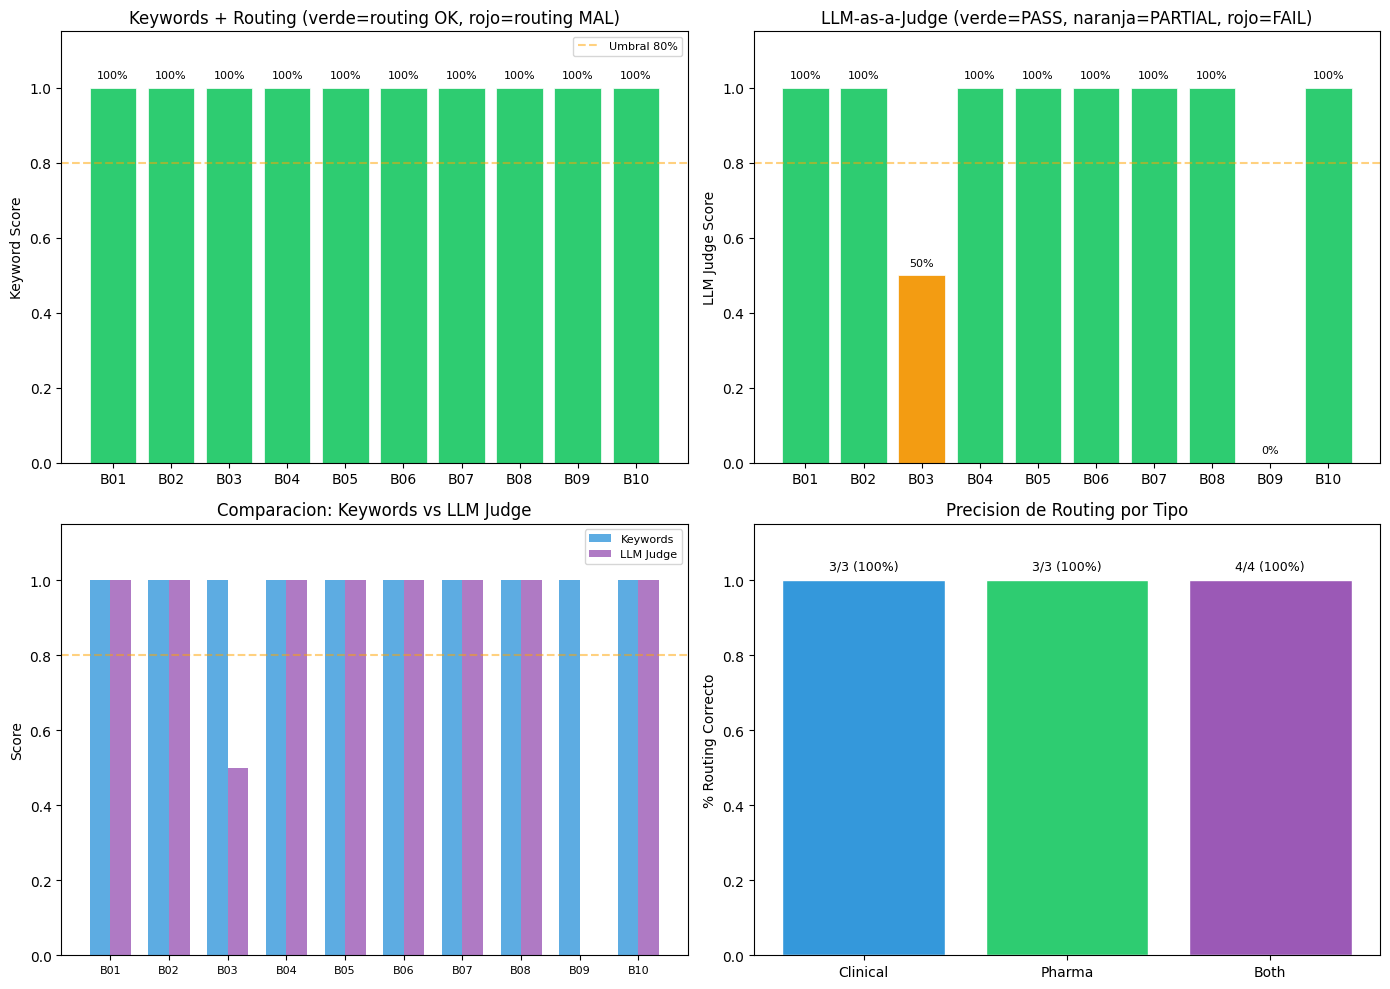

Grafico guardado: benchmark_multiagent.png


In [69]:
# ============================================================
# NO MODIFICAR - Visualizacion
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Keywords + Routing
ax1 = axes[0, 0]
ids = [r["id"] for r in keyword_results]
scores = [r["kw_score"] for r in keyword_results]
colors = ["#2ecc71" if r["routing_correct"] else "#e74c3c" for r in keyword_results]
bars = ax1.bar(ids, scores, color=colors, edgecolor="white", linewidth=0.5)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel("Keyword Score")
ax1.set_title("Keywords + Routing (verde=routing OK, rojo=routing MAL)")
ax1.axhline(y=0.8, color="orange", linestyle="--", alpha=0.5, label="Umbral 80%")
for bar, score in zip(bars, scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{score:.0%}", ha="center", va="bottom", fontsize=8)
ax1.legend(fontsize=8)

# Panel 2: LLM Judge
ax2 = axes[0, 1]
j_scores = [r["score"] for r in judge_results]
j_colors = ["#2ecc71" if r["status"] == "PASS" else "#f39c12" if r["status"] == "PARTIAL" else "#e74c3c" for r in judge_results]
bars2 = ax2.bar(ids, j_scores, color=j_colors, edgecolor="white", linewidth=0.5)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel("LLM Judge Score")
ax2.set_title("LLM-as-a-Judge (verde=PASS, naranja=PARTIAL, rojo=FAIL)")
ax2.axhline(y=0.8, color="orange", linestyle="--", alpha=0.5)
for bar, score in zip(bars2, j_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{score:.0%}", ha="center", va="bottom", fontsize=8)

# Panel 3: Comparacion global
ax3 = axes[1, 0]
x = np.arange(len(ids))
width = 0.35
ax3.bar(x - width/2, scores, width, label="Keywords", color="#3498db", alpha=0.8)
ax3.bar(x + width/2, j_scores, width, label="LLM Judge", color="#9b59b6", alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(ids, fontsize=8)
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("Score")
ax3.set_title("Comparacion: Keywords vs LLM Judge")
ax3.legend(fontsize=8)
ax3.axhline(y=0.8, color="orange", linestyle="--", alpha=0.5)

# Panel 4: Routing por tipo
ax4 = axes[1, 1]
routing_types = ["clinical", "pharma", "both"]
routing_correct_by_type = {}
routing_total_by_type = {}
for r in keyword_results:
    rt = r["expected_routing"]
    routing_total_by_type[rt] = routing_total_by_type.get(rt, 0) + 1
    if r["routing_correct"]:
        routing_correct_by_type[rt] = routing_correct_by_type.get(rt, 0) + 1
rt_labels = []
rt_correct = []
rt_total = []
for rt in routing_types:
    if rt in routing_total_by_type:
        rt_labels.append(rt.capitalize())
        rt_correct.append(routing_correct_by_type.get(rt, 0))
        rt_total.append(routing_total_by_type[rt])
rt_pcts = [c/t if t > 0 else 0 for c, t in zip(rt_correct, rt_total)]
bars4 = ax4.bar(rt_labels, rt_pcts, color=["#3498db", "#2ecc71", "#9b59b6"], edgecolor="white")
ax4.set_ylim(0, 1.15)
ax4.set_ylabel("% Routing Correcto")
ax4.set_title("Precision de Routing por Tipo")
for bar, pct, c, t in zip(bars4, rt_pcts, rt_correct, rt_total):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{c}/{t} ({pct:.0%})", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("benchmark_multiagent.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado: benchmark_multiagent.png")

---

## Ejercicio 5: Analizar resultados

Mira los graficos del benchmark y responde:
- Que preguntas tuvieron routing incorrecto? Por que?
- Hay diferencia entre el score de keywords y el de LLM Judge? Que explica la diferencia?
- Que tipo de preguntas (clinical, pharma, both) tiene mejor routing?

- No se registraron preguntas con routing incorrecto. Las diez consultas del benchmark fueron hechas al agente correspondiente. Creemos que esto sucede gracias claridad en el diseño del system prompt del supervisor, donde se definieron reglas explícitas para distinguir entre preguntas clínicas, farmacológicas y mixtas. Además, los docstrings de las tools contribuyeron a reducir la ambigüedad, permitiendo que el modelo identifique con precisión qué agente utilizar en cada caso.

- Sí, hay una diferencia bastante clara entre ambos scores. Con keywords nos dio 100%, pero con el LLM Judge baja a 85%, y eso pasa por cómo evalúa cada uno. El de keywords es bastante “superficial”, porque solo chequea que aparezcan ciertas palabras o números en la respuesta. Entonces mientras el agente mencione cosas como “68%” u “osimertinib”, ya cuenta como correcto, aunque la respuesta esté incompleta o no termine de contestar bien la pregunta.
En cambio, el LLM Judge evalúa más en profundidad, es decir, si realmente está la información clave y si la respuesta tiene sentido en el contexto. Por ejemplo, en B03 estaban las keywords pero faltó hacer la comparación con osimertinib, entonces quedó como partial. Y en B09 directamente falló porque no dio ninguna opción de segunda línea. 


- No observamos diferencias en el rendimiento de routing entre los distintos tipos de preguntas, ya que todas (clinical, pharma y both) fueron hechas al agente correcto. 

---

## Ejercicio 6: Preguntas conceptuales

### 6.1 -- Routing del supervisor

**Pregunta:** Como decide el supervisor a que agente derivar cada pregunta? Que papel juega el docstring de cada tool de routing?

El supervisor decide a qué agente derivar cada pregunta analizando la intención del usuario y comparándola con las capacidades de cada agente definidas en el system prompt. En base a esto, selecciona la tool de routing más adecuada (clínico, farmacológico o ambos).
En este proceso, los docstrings cumplen un rol fundamental, ya que funcionan como la “documentación operativa” que el modelo lee para entender cuándo debe usar cada tool. Cuanto más claros, específicos y con ejemplos sean estos docstrings, menor es la ambigüedad y más preciso es el routing. En otras palabras, los docstrings guían directamente la toma de decisiones del supervisor.

### 6.2 -- Ventajas y desventajas

**Pregunta:** Cuales son las ventajas y desventajas de usar un patron supervisor vs. un solo agente con todas las tools?

El uso de supervisor presenta varias ventajas frente a un único agente con todas las tools. Permite una mejor especialización, ya que cada sub-agente tiene un dominio bien definido (por ejemplo, clínico o farmacológico), lo que mejora la calidad y precisión de las respuestas. Además, se pueden agregar nuevos agentes sin modificar los existentes. También mejora el control y la interpretabilidad, dado que el routing permite entender qué parte del sistema respondió cada consulta. Sin embargo, este enfoque también tiene sus desventajas. Su diseño es más complejo, ya que necesita definir correctamente el supervisor, los prompts y las reglas de enrutamiento. Por otro lado, existe el riesgo de errores de routing, donde una pregunta se deriva al agente incorrecto, afectando la calidad de la respuesta. 
Un único agente con todas las tools es más simple de implementar, pero suele ser menos preciso y más difícil de escalar o mantener a medida que crece la complejidad del sistema.

### 6.3 -- Preguntas cruzadas

**Pregunta:** Por que las preguntas que cruzan ambos dominios son las mas dificiles para el sistema?

Las preguntas que cruzan ambos dominios son las más difíciles porque el sistema primero tiene que entender que no alcanza con un solo agente. No es solo clasificar entre “pharma” o “clinical”, sino detectar que hay dos cosas distintas pasando en la misma pregunta. Ahí el problema es que si el supervisor se equivoca y manda a un solo agente, la respuesta queda incompleta. Además, incluso cuando usa ambos agentes, después hay que combinar respuestas que vienen de contextos distintos, y eso puede generar respuestas medio desbalanceadas o poco integradas. Hay más puntos donde puede fallar: en el routing y en la integración.


### 6.4 -- Como mejorarias el sistema?

**Pregunta:** Propone al menos 3 mejoras concretas al sistema multiagente.

Para mejorar el sistema, primero, mejoraríamos el supervisor prompt agregando más ejemplos de preguntas mixtas, porque eso ayuda mucho a que detecte mejor cuándo usar ambos agentes. Segundo, estandarizaríamos más las respuestas de los agentes (por ejemplo, que ambos sigan estructuras parecidas), así cuando se combinan quedan más coherentes y no parecen dos respuestas pegadas. Tercero, agregaríamos algún tipo de validación en el supervisor, por ejemplo que si la respuesta parece incompleta o menciona solo un dominio, vuelva a intentar usando el otro agente.